In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("../beam_search_summary.csv")
df

,dataset,beam_width,num_results,avg_edges_1.0,avg_edges_0.99,avg_edges_0.98,avg_edges_0.97,avg_edges_0.96,avg_edges_0.95,avg_edges_0.94,...,train_expanded_0.9125,train_recall_0.9075,train_seen_0.9075,train_expanded_0.9075,train_recall_0.905,train_seen_0.905,train_expanded_0.905,train_recall_0.9025,train_seen_0.9025,train_expanded_0.9025
0,mnist,1,1,19.637517,7.86125,6.475683,5.707333,5.181833,4.7878,4.476083,...,6.35,0.03,22.16,6.06,0.03,22.16,6.13,0.02,22.00,6.04
1,mnist,10,1,19.637517,7.86125,6.475683,5.707333,5.181833,4.7878,4.476083,...,26.77,0.36,91.12,27.02,0.36,90.19,27.07,0.38,90.58,27.53
2,mnist,100,1,19.637517,7.86125,6.475683,5.707333,5.181833,4.7878,4.476083,...,132.23,0.63,362.04,132.39,0.63,357.76,132.29,0.62,354.94,132.67


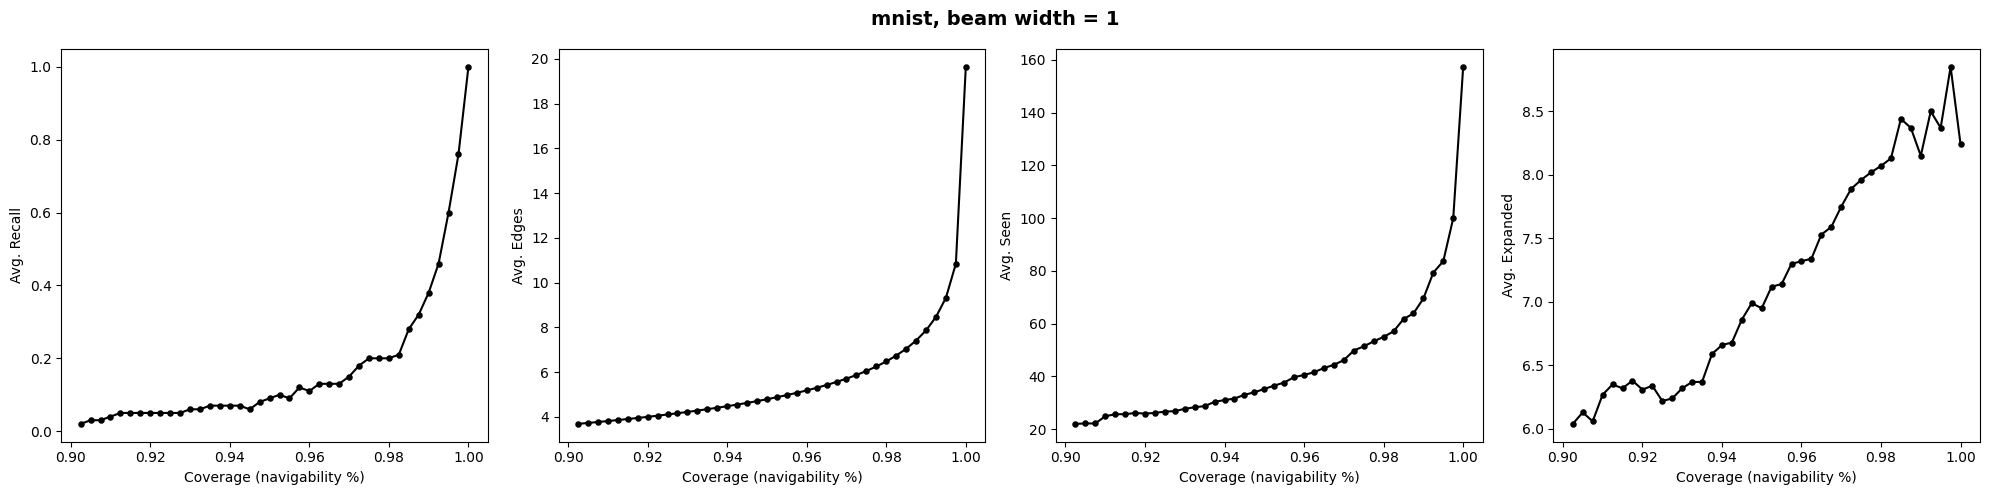

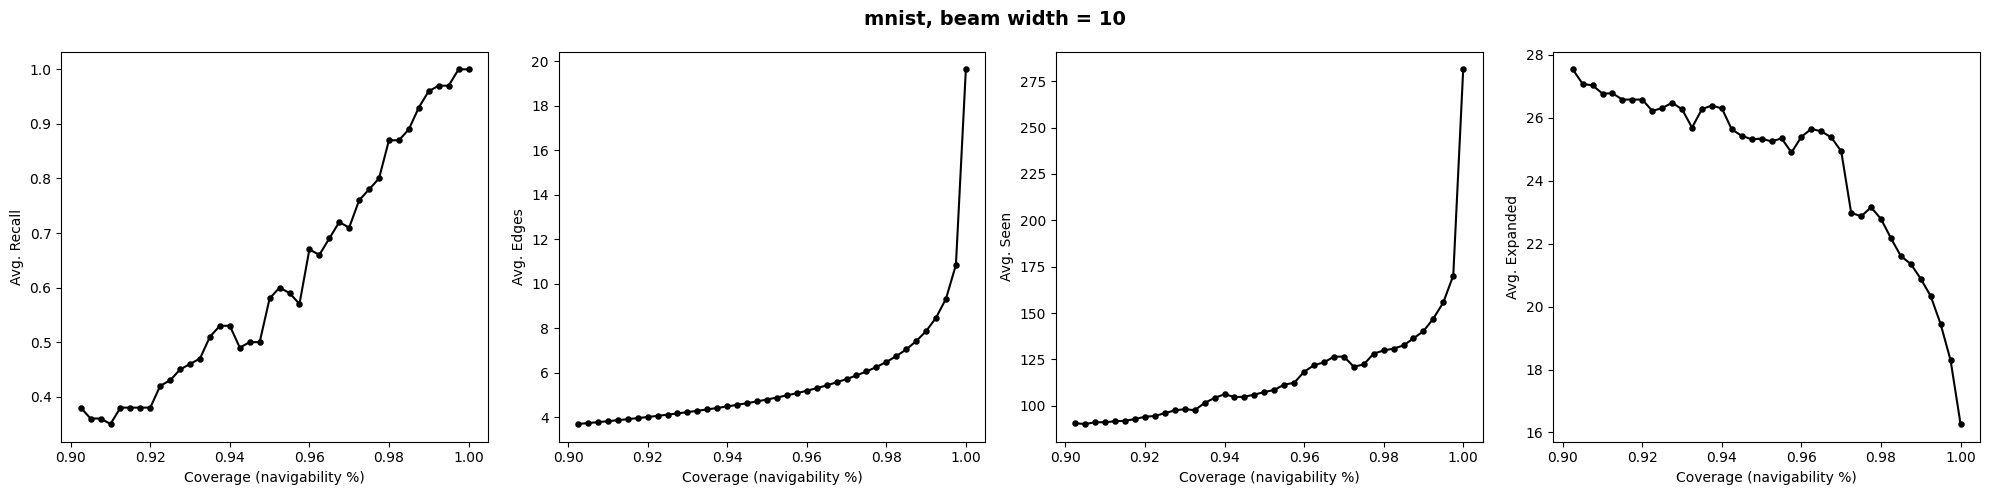

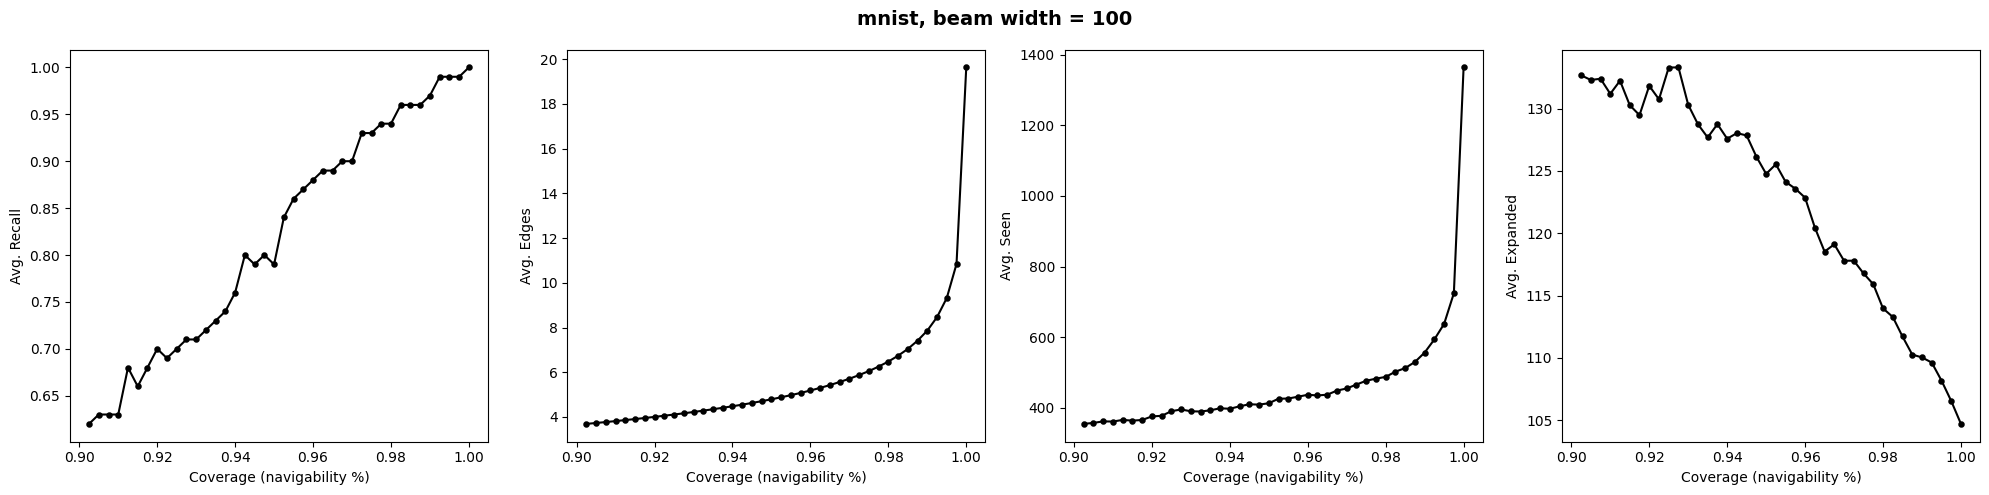

In [39]:
import re

plt.style.use('default')

TRAIN_COLOR = 'black'

for _, row in df.iterrows():
    coverages = sorted(
        [float(re.search(r'avg_edges_(.+)', c).group(1))
         for c in df.columns if c.startswith('avg_edges_')],
        reverse=True
    )

    avg_edges      = [row[f'avg_edges_{v}']      for v in coverages]
    train_recall   = [row[f'train_recall_{v}']   for v in coverages]
    train_seen     = [row[f'train_seen_{v}']     for v in coverages]
    train_expanded = [row[f'train_expanded_{v}'] for v in coverages]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"{row['dataset']}, beam width = {row['beam_width']}", fontsize=14, fontweight='bold')

    plot_specs = [
        {'ylabel': 'Avg. Recall',   'train_y': train_recall},
        {'ylabel': 'Avg. Edges',    'train_y': avg_edges},
        {'ylabel': 'Avg. Seen',     'train_y': train_seen},
        {'ylabel': 'Avg. Expanded', 'train_y': train_expanded},
    ]

    for ax, spec in zip(axes, plot_specs):
        ax.plot(coverages, spec['train_y'], color=TRAIN_COLOR, linewidth=1.5)
        for xi, yi in zip(coverages, spec['train_y']):
            ax.scatter(xi, yi, color=TRAIN_COLOR, s=10, zorder=5, linewidths=1.5)
            # ax.text(xi, yi, f'{xi}', ha='center', va='center', fontsize=5, color=TRAIN_COLOR, zorder=3)
        ax.set_xlabel('Coverage (navigability %)')
        ax.set_ylabel(spec['ylabel'])

    plt.tight_layout()
    plt.show()
